Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Topic modeling
from sklearn.decomposition import LatentDirichletAllocation

# Recommendations
from sklearn.metrics.pairwise import cosine_similarity

# Display settings
pd.set_option('display.max_colwidth', 300)
sns.set(style='whitegrid')

In [2]:
df=pd.read_csv("/kaggle/input/amazon-reviews-dataset/Amazon_Reviews.csv",engine='python')
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I sent them over. They said they would review them within 24 hours. In reality, it's been a week, an...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,"Had multiple orders one turned up and driver had to phone as no door number on packaging, then waited all day for second package to get a message saying couldn't deliver as no number on packaging, 12 hours waiting in now don't even know when I'm getting delivery. Terrible will never use again","September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,"I informed these reprobates that I WOULD NOT BE IN as I was going to visit a sick relative, they told me they were going to send a OTP, I told them I could not receive it as I was travelling a long way on the underground, their reply was don’t worry we can text. I pointed out I can’t receive tex...","September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no problems being very happy with the service and price. Amazon advertise the product at 61.23 us as soon as I logged in and tried to buy two of the items they were 86.75 for each.There is no way of contacting customer service I've spent an hour going round a...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancelled my Amazon Prime in February and subsequently found that they had continued to charge me. When I contacted them they refused to give details of who had set up the payment as I didn't have Prime membership at that time. My credit card company cance...,"September 16, 2024"


Очистка данных

In [3]:
df = df[['Rating', 'Review Title', 'Review Text', 'Country']] # Нужные столбцы из датафрейма
        
df_clean = df.copy() # Копия очищенного датафрейма
        
df_clean['Review Text'] = ( #Очистка текста отзыва
    df_clean['Review Text'].astype(str) # Строковый тип
    .str.strip() # Удаляем пробелы вначале и вконце
    .str.replace(r'http\S+|www\S+', ' ', regex=True) # URL-адреса
    .str.replace(r'<.*?>', ' ', regex=True) # HTML-теги
)
df_clean = df_clean[df_clean['Review Text'].str.len()>5] # Фильтрация коротких текстов
df_clean = df_clean[df_clean['Review Text'].str.contains(r'[A-Za-z0-9]')] # Оставляем только строки с буквами и цифрами
                        
df_clean['Review Title'] = ( # Очистка заголовков 
    df_clean['Review Title'] # Берём заголовок
    .astype(str) # Приводим к строковому типу
    .str.strip() # Удаляем пробелы 
    .str.replace(r'<.*?>', ' ', regex=True) # Удаляем HTML теги
    .str.replace(r'http\S+|www\S+', ' ', regex=True) # Удаляем URL
    .str.replace(r'\s+', ' ', regex=True) # Удаляем множественные пробелы 
)
df_clean = df_clean[df_clean['Review Title'].str.len()>2] # Удаляем короткие заголовки

df_clean['Rating'] = df_clean['Rating'].astype(str).str.extract(r'(\d)').astype(float) # К строке, извлекаем цифры, преобразуем в число
df_clean = df_clean.dropna(subset=['Rating']) # Удаляем строки с пропущенными рейтингами
df_clean['Rating'] = df_clean['Rating'].astype(int) # Приводим рейтинг к целому числу
df_clean = df_clean[df_clean['Rating'].between(1, 5)] # Оставляем рейтинг от 1 до 5

df_clean['Country'] = ( # Очистка стран
    df_clean['Country'] # Берём страну
    .astype(str) # Приводим к строке
    .str.strip() # Удаляем пробелы
    .str.replace(r'[^A-Za-z ]', ' ', regex=True) # Удаляем небуквенные символы
    .str.replace(r'\s+', ' ', regex=True) # Удаляем множественные пробелы
    .str.title() # Приводим к регистру
)
df_clean = df_clean[df_clean['Country'].str.len() > 1] # Фильтрация коротких названий стран

df_clean = df_clean.dropna() # Удаляем строки с пропусками
df_clean = df_clean.drop_duplicates(subset=['Review Text']) # Удаляем дубликаты по тексту отзыва

df_clean['Sentiment'] = df_clean['Rating'].apply(lambda x: 1 if x >= 4 else (0 if x == 3 else -1)) # Создаём колонку оценки на основе рейтинга
df_clean = df_clean[df_clean['Sentiment']!= 0]

df_clean.head()

,Rating,Review Title,Review Text,Country,Sentiment
0,1,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I sent them over. They said they would review them within 24 hours. In reality, it's been a week, an...",Us,-1
1,1,Had multiple orders one turned up and…,"Had multiple orders one turned up and driver had to phone as no door number on packaging, then waited all day for second package to get a message saying couldn't deliver as no number on packaging, 12 hours waiting in now don't even know when I'm getting delivery. Terrible will never use again",Gb,-1
2,1,I informed these reprobates,"I informed these reprobates that I WOULD NOT BE IN as I was going to visit a sick relative, they told me they were going to send a OTP, I told them I could not receive it as I was travelling a long way on the underground, their reply was don’t worry we can text. I pointed out I can’t receive tex...",Gb,-1
3,1,Advertise one price then increase it on website,I have bought from Amazon before and no problems being very happy with the service and price. Amazon advertise the product at 61.23 us as soon as I logged in and tried to buy two of the items they were 86.75 for each.There is no way of contacting customer service I've spent an hour going round a...,Au,-1
4,1,If I could give a lower rate I would,If I could give a lower rate I would! I cancelled my Amazon Prime in February and subsequently found that they had continued to charge me. When I contacted them they refused to give details of who had set up the payment as I didn't have Prime membership at that time. My credit card company cance...,Gb,-1


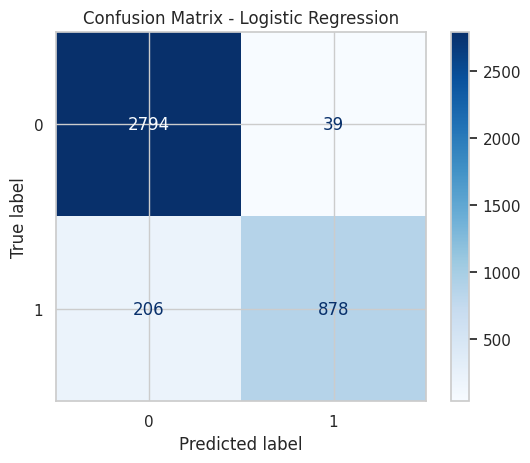

In [4]:
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from nltk.corpus import stopwords

X_train, X_test, y_train, y_test = train_test_split(
    df_clean['Review Text'], df_clean['Sentiment'], test_size=0.2, random_state=42 # Тексты, целевые значения, 20% данных для текста, для воспроизводимости
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_features=10000) # удаление английских стоп-слов, кол-во признаков
X_train_vec = vectorizer.fit_transform(X_train) # обучение и преобразование обучающей выборки
X_test_vec = vectorizer.transform(X_test) # Преобразование тестовой выборки

model = LogisticRegression(max_iter=2000) #Увеличение кол-во итераций для сходимости
model.fit(X_train_vec, y_train) # Обучение модели
y_pred = model.predict(X_test_vec) # Получение предсказаний

cm = confusion_matrix(y_test, y_pred) # Матрица ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot(cmap='Blues') # Визуализация матриц ошибок
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Обучение модели

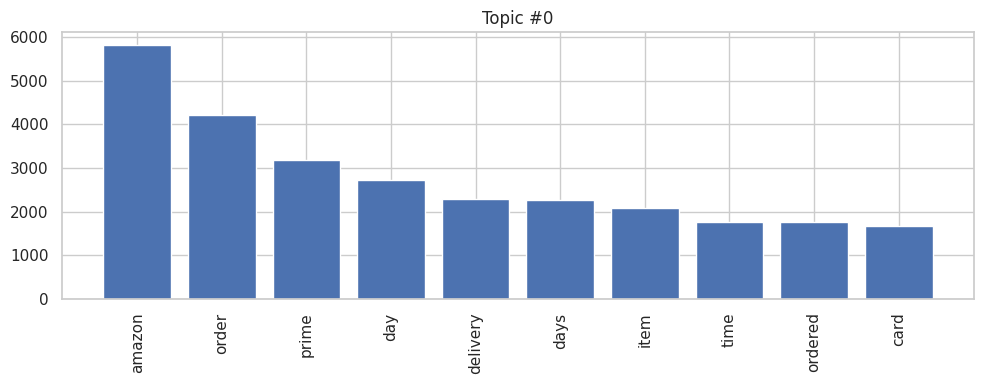

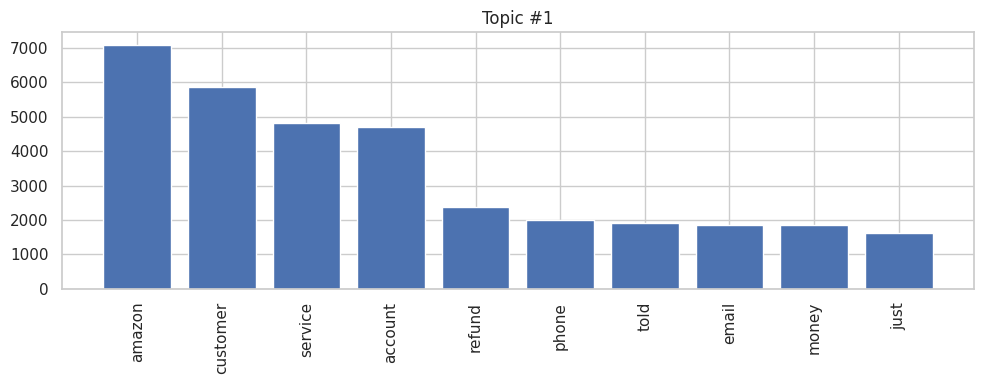

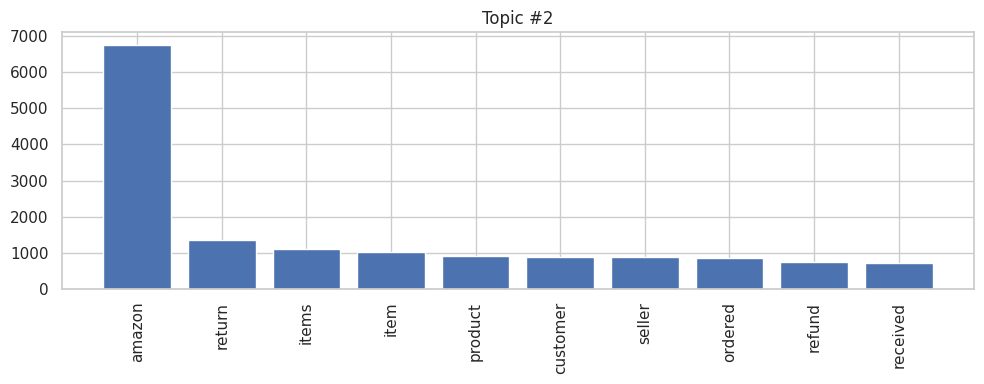

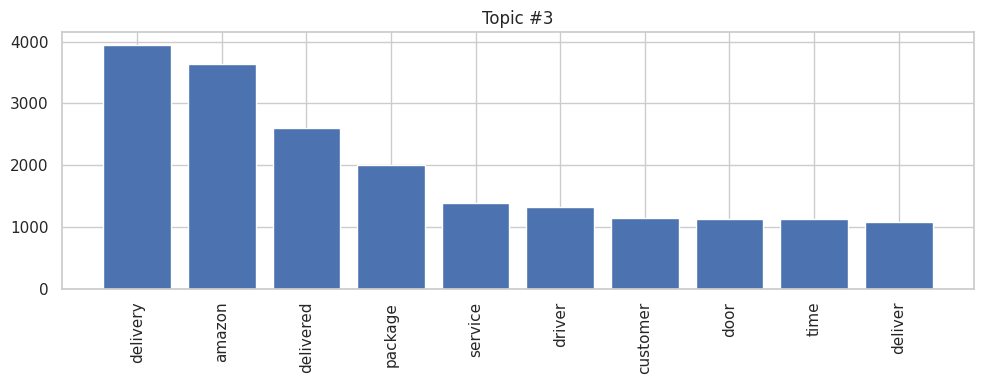

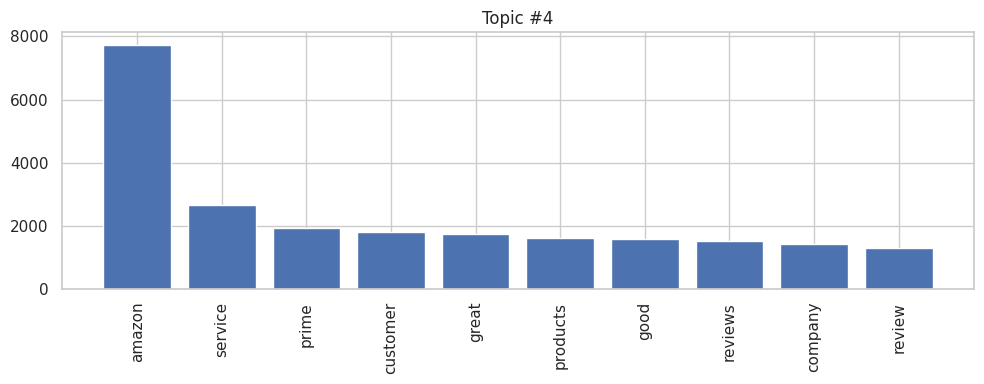

In [5]:
count_vect = CountVectorizer(stop_words='english', max_features=5000) # TF-IDF векторизатор, удаление английских слов, максимальное число признаков
X_counts = count_vect.fit_transform(df_clean['Review Text']) # Преобразование текста

lda = LatentDirichletAllocation(n_components=5, random_state=42) # LDA модель, кол-во тем, для воспроизводимости
lda.fit(X_counts) # Обучение модели

def plot_lda_topics(model, feature_names, n_top_words=10): # Функия для визуализации тем
    for topic_idx, topic in enumerate(model.components_): # Перебираем каждую тему
        top_indices = topic.argsort()[::-1][:n_top_words] # Находим индексы топ-слов
        words = [feature_names[i] for i in top_indices] # Получаем сами слова и их веса
        values = topic[top_indices]

        plt.figure(figsize=(10,4)) # Визуализация
        plt.bar(words, values)
        plt.title(f'Topic #{topic_idx}')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

plot_lda_topics(lda, count_vect.get_feature_names_out())

In [6]:
df_clean.to_csv('clean_reviews.csv', index=False)

Графики с данными

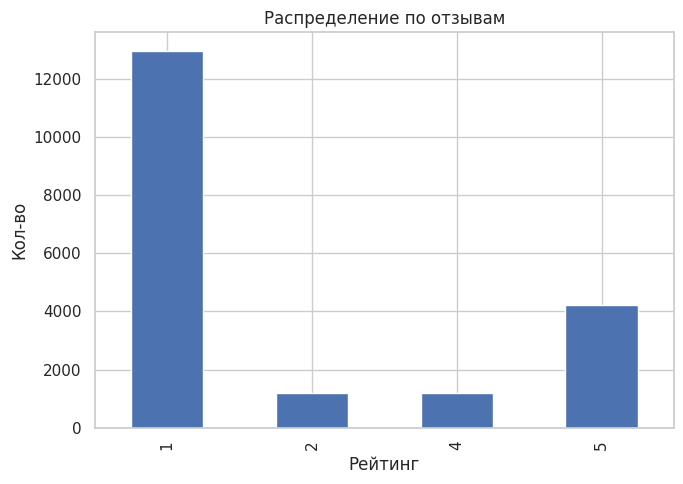

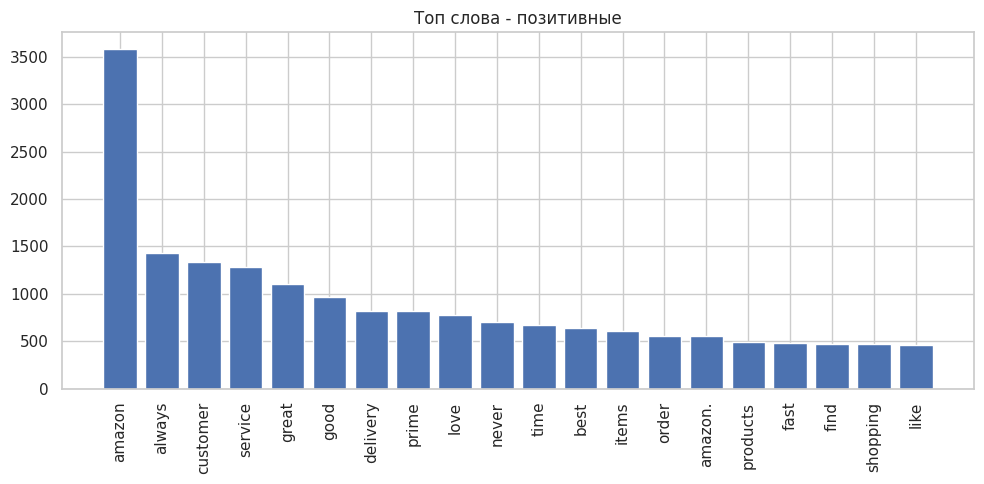

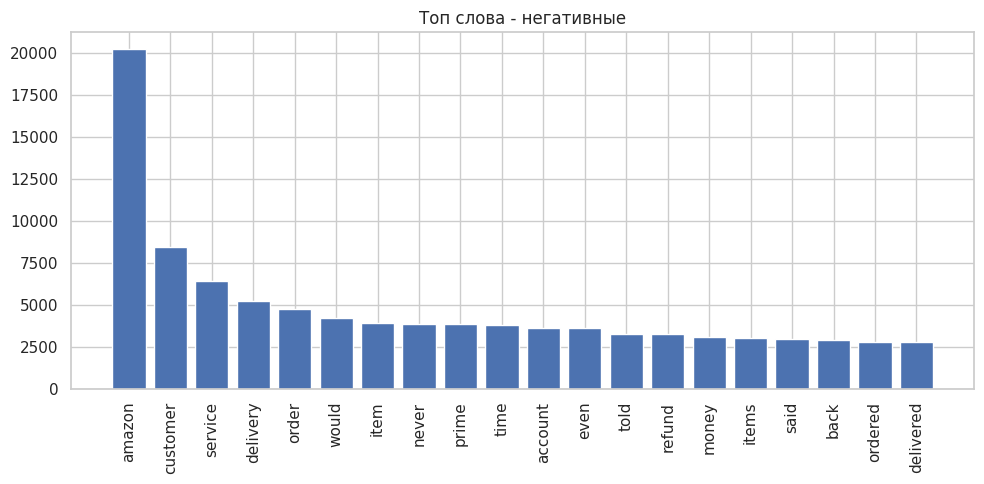

In [7]:
plt.figure(figsize=(7,5)) 
df_clean['Rating'].value_counts().sort_index().plot(kind='bar') # Строим гистограмму
plt.title('Распределение по отзывам')
plt.xlabel('Рейтинг')
plt.ylabel('Кол-во')
plt.tight_layout() # Автоматическое расположение элементов
plt.show()

stop_words = set(stopwords.words('english'))

def plot_top_words(texts, title, n=20):
    words = []
    for text in texts:
        words.extend([
            w for w in text.lower().split()
            if w not in stop_words and len(w) > 3
        ])
    counter = Counter(words) # Подсчёт частоты слов
    labels, values = zip(*counter.most_common(n)) # Разделение на метки и значения

    plt.figure(figsize=(10,5)) 
    plt.bar(labels, values) # Столбачатая диаграммы
    plt.xticks(rotation=90) 
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_words(df_clean[df_clean['Sentiment']==1]['Review Text'], 'Топ слова - позитивные') # Визуализация для позитивных отзывов

plot_top_words(df_clean[df_clean['Sentiment']==-1]['Review Text'], 'Топ слова - негативные') # Визуализация для негативых отзывов

ROC-AUC

ROC-AUC: 0.9823477713245187


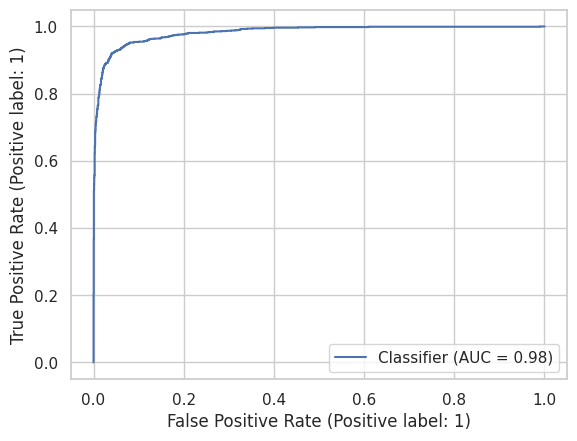

In [8]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = model.predict_proba(X_test_vec)[:,1]
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

In [9]:
acc = accuracy_score(y_test, y_pred)
print('Accuraccy', acc)

Accuraccy 0.9374521317334695


Топ слов модели

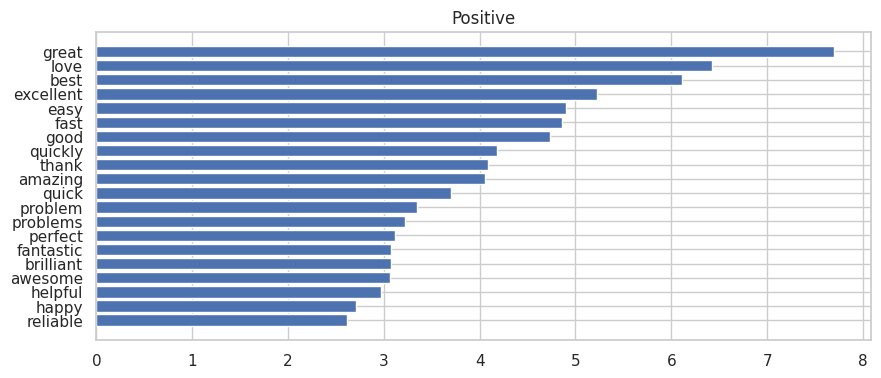

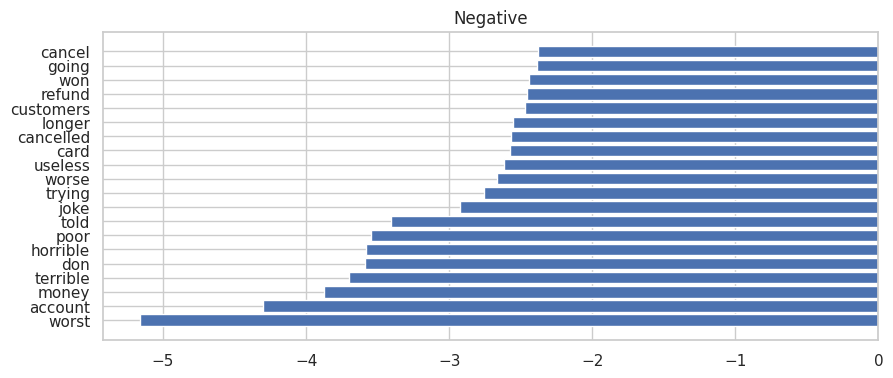

In [10]:
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_pos = np.argsort(coef)[-20:]
top_neg = np.argsort(coef)[:20]

plt.figure(figsize=(10,4))
plt.barh(feature_names[top_pos], coef[top_pos])
plt.title('Positive')
plt.show()

plt.figure(figsize=(10,4))
plt.barh(feature_names[top_neg], coef[top_neg])
plt.title('Negative')
plt.show()

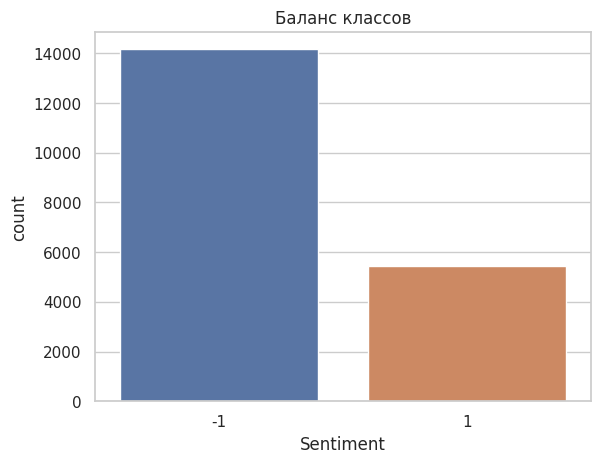

In [11]:
sns.countplot(x=df_clean['Sentiment'])
plt.title('Баланс классов')
plt.show()

In [12]:
errors_df = X_test.reset_index(drop=True).to_frame(name='Review Text')
errors_df['True'] = y_test.reset_index(drop=True)
errors_df['Pred'] = y_pred

In [13]:
errors_df['Proba_Positive'] = y_proba

In [14]:
false_positives = errors_df[
    (errors_df['True'] == -1) &
    (errors_df['Pred'] == 1)
]

false_positives.head(10)

,Review Text,True,Pred,Proba_Positive
135,"Their ""Free Shipping"" has become relegated to the Post Office.\rThey are NOT freight shippers!!! Boxes usually end up broken, retaped, badly mistreated but Amazon doesnt care its cheap!\rIts NOT Free for us, one still has to get to the PO and since when is the price of gas free???\rIm looking e...",-1,1,0.564189
164,AFTER BEING A CUSTOMER FOR 3 YEARS YOU HAVE REJECTED EVERY ITEM IVE TRIED TO ORDER AND MADE ME ARGUE THAT I AM NOT A FRAUD ON MY OWN ACCOUNT. FOR TWO YEARS. EVERY ITEM! NEVER AN EASY ORDER OR TIME. I HIGHLY DO NOT RECOMMEND USING THIS SITE EVER ☺️,-1,1,0.640044
671,Third class service.Not to use Amazon shipping services.,-1,1,0.648131
750,Bought some CD's from Amazon. Three out of the five the cases were shatered. Spoke to custom services and they seemed to think that the cases didnt matter and if the CD's plaid then it was ok. Got them swapped eventually but it wasnt easy to do.,-1,1,0.679013
760,"Fifty percent of the time you will get opened, damaged products. Avoid amazon like the plague. Go get some exercise and buy your stuff at real stores. Easier to return, get a refund. A salesman makes you feel good when you buy stuff. A sheister makes you feel bad, like you got ripped off. ...",-1,1,0.503509
831,"Been Amazon Prime for 2-3 years. I have had SO many 'issues' with them, that I really don't know why I continue to order the occasional thing from them. Some of the 'issues' they managed to correct, or at least make some compensation for - but there's a couple that they just can't seem to comp...",-1,1,0.532808
845,Amazon the cheapest quality ever from online . Very very disappointed 😔. They had something nice in picture but wen you get the stuff than oh my god . Totally opposite from the picture . Very bad experienced It’s all made from China... never shop again,-1,1,0.565344
859,"If you're just a customer of Amazon, you most likely love them. If you're involved with Amazon deeper than just buying, you probably feel like me. They can be extremely unpleasant and difficult to deal with. Also, their ""free shipping"" isn't really free.",-1,1,0.731557
1004,"Rude, confrontational with there reply and not helpful with returning products. They are cheap products and they def are cheap. Wish I had checked trustpilot before buying of them. Never had any issue with any Amazon orders or returns before. Reported to Amazon. If you want cheap items and know...",-1,1,0.523763
1099,Had an issue with a order not really thier fault however I found the chat associate dismissive abrupt and eager to get rid of me think the name was Tamira something like that.,-1,1,0.614174


In [15]:
false_negatives = errors_df[
    (errors_df['True'] == 1) &
    (errors_df['Pred'] == -1)
]

false_negatives.head(10)

,Review Text,True,Pred,Proba_Positive
23,"If you purchase an item from Amazon and write a review it is posted whether good or bad. Maybe I've just been lucky, but I have never been disappointed by the results of any complaints I have made.",1,-1,0.341774
44,"I have been using Amazon for many years and have done hundreds of purchases with them. A lot of the times they are cheaper than others like eBay, Home Depot, or even Walmart. While I've still purchased from the others I have many times purchased Amazon over them even when they are more expensive...",1,-1,0.498668
67,"Thought I would leave a review. I must admit I was totally surprised at the bad reviews. I have used amazon for years with not one issue order in the morning delivery same day. Surely you cannot get better than that. Once an item did not arrive by arrival date(Royal Mail) requested a refund , gi...",1,-1,0.190437
84,There is nothing better than the quickness and accuracy of Amazon.,1,-1,0.429199
93,"Long term customer, I recently had an issue with an order I placed on Black Friday. I understand that mistakes happen and its a rarity but how they sorted it mattered.They were fantastic about sorting it out, gave me a gift voucher for the difference and I was able to get the item the next day a...",1,-1,0.437808
94,"All okay, how can it be 1.7 rating? I can’t understand",1,-1,0.339762
101,I use Amazon almost every day. Almost instant consumer gratification straight to my postbox.,1,-1,0.429817
109,"Having used Amazon for many years and experienced very few problems, they have just gone that extra mile.We ordered an item to be delivered to a location at which we were staying. The courier allegedly could not obtain access, which we questioned. Unfortunately we then returned home. Sent an ema...",1,-1,0.171494
138,"Credible company with excellent customer service. I got scammed once by a third party seller, yet they still refund my money!",1,-1,0.299677
169,"service ok,...",1,-1,0.483084


In [16]:
false_positives.sort_values(
    'Proba_Positive',
    ascending=False
).head(5)

,Review Text,True,Pred,Proba_Positive
1394,Very good service,-1,1,0.960096
2670,Its very best company because it provides all things which are used in our life from online its a e.commerce app,-1,1,0.902509
2259,Nice product,-1,1,0.830859
2111,Overall experience with Amazon is not good. Company can do lot more better for customers referring the history of it's reputation.,-1,1,0.816612
2888,"For me, you find out how good a company is when you've experienced a problem. I've shopped with Amazon for several years and never had a problem. However, I had a problem lately which showed me how really bad their customer service is. As a result, I will be avoiding using Amazon again.",-1,1,0.798589


In [17]:
false_negatives.sort_values(
    'Proba_Positive'
).head(5)

,Review Text,True,Pred,Proba_Positive
957,"From my experience, it looks like Amazon is sneakily supporting BDS.Amazon _CUSTOMER_SUPPORT_+1*8*5*5*2*9*8*25_O7__Amazon _CUSTOMER_SUPPORT_+1*8*5*5*2*9*8*25_O7__Amazon _CUSTOMER_SUPPORT_+1*8*5*5*2*9*8*25_O7__Amazon _CUSTOMER_SUPPORT_+1*8*5*5*2*9*8*25_O7__Amazon _CUSTOMER_SUPPORT_+1*8*5*5*2*9*8*...",1,-1,0.003344
702,"I ordered off a supplier through Amazon, I ordered three of the items and later discovered Amazon charged me 3x the delivery fee. The product was ordered and would be delivered together!! I requested Amazon to refund 2 x the delivery fee and they refused and also decided to argue with me consist...",1,-1,0.038739
2336,"I've been ordering from Amazon for about 5 years now. I have ordered a variety of products, from dog shampoo to Pokemon products. There were a few instances where I ordered something that I ended up festering an allergic reaction to. Even though the listing said no returns, I was able to speak w...",1,-1,0.055223
711,I ordered an Xbox one S controller and they sent me an Xbox series S controller. I tried to contact customer support but it was hard to understand them due to a language barrier. They asked me to write a review and I did exactly that. They read it and refused to post it because I got scammed by ...,1,-1,0.061710
1399,Used it as a seller for more than a year.,1,-1,0.073106


In [18]:
errors_df['Length'] = errors_df['Review Text'].str.len()

errors_df.groupby(
    ['True', 'Pred']
)['Length'].mean()

True  Pred
-1    -1      587.023980
       1      317.230769
 1    -1      345.247573
       1      195.164009
Name: Length, dtype: float64

In [19]:
errors_df = errors_df.join(
    df_clean.loc[X_test.index, 'Country'].reset_index(drop=True)
)

errors_df.groupby('Country')['Pred'].count().sort_values(ascending=False).head(10)

Country
Us    1692
Gb    1425
Ca     148
In      95
Ie      52
Dk      43
Au      37
Nl      36
It      30
De      27
Name: Pred, dtype: int64

In [20]:
!pip install pyLDAvis
print('Finish')

Finish


In [21]:
import pyLDAvis
import numpy as np

topic_term_dists = lda.components_ / lda.components_.sum(axis=1)[:, None]
doc_topic_dists = lda.transform(X_counts)
doc_lengths = np.array(X_counts.sum(axis=1)).flatten()
vocab = count_vect.get_feature_names_out()     
term_frequency = X_counts.sum(axis=0).A1       

vis = pyLDAvis.prepare(
    topic_term_dists,
    doc_topic_dists,
    doc_lengths,
    vocab,
    term_frequency
)

pyLDAvis.save_html(vis, 'lda_vis.html')
print('save')

save


In [22]:
def analyze(text):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0].max()
    return pred, prob

while True:
    review = input('Введите отзыв (exit для выхода): ')
    if review.lower() == 'exit':
        break
    sentiment, conf = analyze(review)
    print(f'Тональность: {sentiment}, уверенность: {conf:.2f}\n')

Введите отзыв (exit для выхода):  This things so cool


Тональность: 1, уверенность: 0.68



Введите отзыв (exit для выхода):  exit
